In [754]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import math

# EXPERIMENT 1: CONSTANT APPROXIMATION FOR ALL REGIONS

### 1) Create dynamics

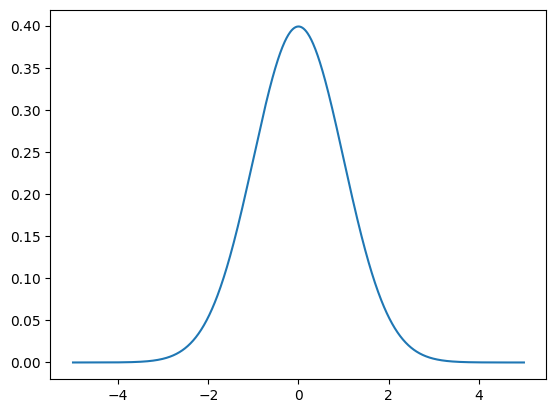

In [755]:
mu, sigma = 0, 1
def f(x):
    coefficient = 1 / (sigma * math.sqrt(2 * math.pi))
    exponent = math.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return coefficient * exponent
    
def global_lipsc():
    return np.exp(-1/2)/2*np.pi

x_data = np.linspace(-5, 5, 1000)
dynamics = [f(x) for x in x_data]
plt.plot(x_data, dynamics)

In [756]:
global_lipsc()

0.9527361323650899

### Compute true Wasserstein

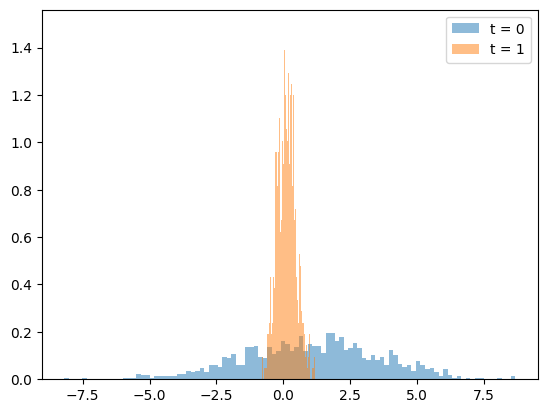

In [757]:
n_samples = 1000

mean_initial = 1
std_dev_initial = 2.5

initial_distribution = norm.rvs(loc = mean_initial, scale = std_dev_initial, size = n_samples)

mean_noise = 0
std_dev_noise = 0.3
noise = norm.rvs(loc = mean_noise, scale = std_dev_noise, size = n_samples)

propagated_states = np.array([f(x) + noise[i] for i, x in enumerate(initial_distribution)])

plt.hist(initial_distribution, alpha=0.5, label='t = 0', bins=100, density=True)
plt.hist(propagated_states, alpha=0.5, label='t = 1', bins=100, density=True)
plt.legend()

<BarContainer object of 10 artists>

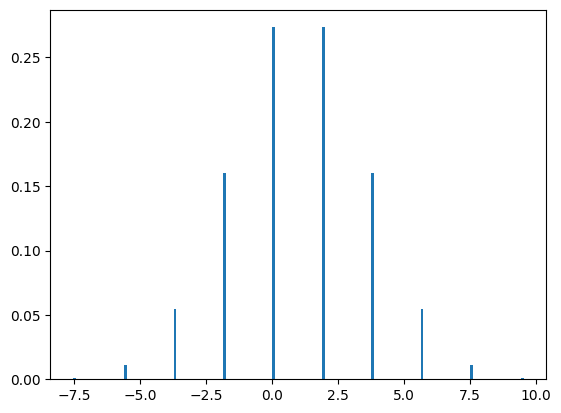

In [758]:
#Create signaturization for initial distribution
points = [-np.inf]
points.extend(list(np.linspace(mean_initial - 3*std_dev_initial, mean_initial + 3*std_dev_initial, 9)))
points.append(np.inf)

initial_signature_probas = [norm.cdf(points[i], loc = mean_initial, scale = std_dev_initial) - norm.cdf(points[i-1], loc = mean_initial, scale = std_dev_initial) for i in range(1, len(points))]

signatures = []
for i in range(1, len(points)):
    if i == 1:
        signatures.append(mean_initial - 3*std_dev_initial - 1)
    elif i == len(points)-1:
        signatures.append(mean_initial + 3*std_dev_initial + 1)
    else:
        signatures.append(points[i-1] + (points[i] - points[i-1])/2)

plt.bar(signatures, initial_signature_probas, width=0.1)

In [759]:
def sample_gmm(points, probabilities, st_dev, n_samples=1):
    
    # Step 1: Choose a component based on the provided probabilities
    chosen_components = np.random.choice(len(points), size=n_samples, p=probabilities)
    
    # Step 2: Sample from the chosen Gaussian component
    samples = np.array([np.random.normal(points[i], st_dev) for i in chosen_components])
    
    return samples

locations = [f(signature) for signature in signatures]
samples_gmm = sample_gmm(locations, initial_signature_probas, std_dev_noise, n_samples=1000)

In [760]:
# Step 1: Convert the sample vector to an empirical probability distribution
initial_distribution, counts = np.unique(initial_distribution, return_counts=True)
empirical_probs = counts / counts.sum()

In [761]:
initial_distribution = np.array(initial_distribution)
empirical_probs = np.array(empirical_probs)

signatures = np.array(signatures)
initial_signature_probas = np.array(initial_signature_probas)

In [762]:
import ot
from ot import dist, emd2

# Compute the cost matrix (squared Euclidean distance between samples)
M = ot.dist(initial_distribution.reshape((len(initial_distribution), 1)), signatures.reshape((len(signatures), 1)), metric = 'sqeuclidean')

# Compute the squared Wasserstein distance
wasserstein2_sq = ot.emd2(empirical_probs, initial_signature_probas, M)


In [763]:
dist_initial_sq = wasserstein2_sq
dist_initial_sq ** 0.5

0.551324453052841

In [764]:
# Compute the cost matrix (squared Euclidean distance between samples)
M = ot.dist(samples_gmm.reshape((len(samples_gmm), 1)), propagated_states.reshape((len(propagated_states), 1)), metric = 'sqeuclidean')

# Compute the squared Wasserstein distance
wasserstein2_sq_TRUE = ot.emd2([], [], M)

wasserstein2_sq_TRUE**0.5

0.033383517093092

### Propagating with global Lipschitz

In [765]:
(global_lipsc()**2 * dist_initial_sq)**0.5

0.5252667270798623

In [766]:
def build_regions(states):
    regions = []
    for i, state in enumerate(states):
        if i == 0:
            regions.append([-np.inf, state + (states[i+1] - state)/2])
        elif i == len(states) - 1:
            regions.append([state - (state - states[i-1])/2, np.inf])
        else:
            regions.append([state - (state - states[i-1])/2, state + (states[i+1] - state)/2])
    return regions

In [767]:
regions = build_regions(signatures)

### NEW METHOD

In [768]:
def computeConstantOverapproximation(region_1, region_2):
    #This is a (good) proxy

    a_0, b_0 = region_1[0], region_1[1]
    a_1, b_1 = region_2[0], region_2[1]

    max_value = 0

    max_value = max(max_value, abs(f(a_0) - f(a_1)))
    max_value = max(max_value, abs(f(a_0) - f(b_1)))
    max_value = max(max_value, abs(f(b_0) - f(a_1)))
    max_value = max(max_value, abs(f(b_0) - f(b_1)))

    return max_value

In [769]:
omega = np.ones((len(regions), len(regions)))

In [770]:
projection_matrix = np.zeros((len(regions), len(regions)))

for i in range(len(regions)):
    for j in range(len(regions)):

        project = 0
        if(signatures[j] <= regions[i][0]):
            project = regions[i][0] - signatures[j]
        elif(signatures[j] >= regions[i][1]):
            project = signatures[j] - regions[i][1]

        projection_matrix[i][j] = project ** 2

#projection_matrix

In [771]:
beta = np.zeros((len(regions), len(regions)))

for i in range(len(regions)):
    for j in range(len(regions)):
        
        interval_approx = computeConstantOverapproximation(regions[i], regions[j])

        beta[i][j] = interval_approx ** 2

#beta

In [772]:
def compute_a(k, l, omega):
    
    value = 0
    
    for n in range(len(regions)):

        value += omega[k][n] * initial_signature_probas[n] * beta[k][n] * (2 - omega[l][n])

    return value

In [773]:
def projection_on_subspace(omega, proba_vector):

    ones = np.ones(len(proba_vector))
    factor = np.dot(proba_vector, proba_vector)
    c = (ones - np.dot(omega, proba_vector)) / factor

    return omega + np.outer(c, proba_vector)

In [774]:
import autograd.numpy as np  # Thinly-wrapped numpy
from autograd import grad    # The only autograd function you may ever need

def compute(lambda_param, omega):

    outer_sum = 0

    for i in range(len(regions)):
        for j in range(len(regions)):

            max_value = -np.infty

            for k in range(len(regions)):
                for l in range(len(regions)):
                    value = compute_a(k, l, omega) - lambda_param * projection_matrix[k][i] - lambda_param * projection_matrix[l][j]

                    max_value = max(max_value, value)

            outer_sum += initial_signature_probas[i] * initial_signature_probas[j] * max_value

    outer_sum += lambda_param * 2 * dist_initial_sq

    return outer_sum**0.5

grad_lambda = grad(compute, 0)
grad_omega = grad(compute, 1)

In [775]:
#lambda_param = 0.1
#omega = np.ones((len(regions), len(regions)))

In [776]:
def adam_update(lambda_param, omega, grad_lambda, grad_omega, m_lambda, v_lambda, m_omega, v_omega, t, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-6):
    
    # Increment time step
    t += 1
    
    # Update moment estimates for lambda
    m_lambda = beta1 * m_lambda + (1 - beta1) * grad_lambda
    v_lambda = beta2 * v_lambda + (1 - beta2) * (grad_lambda ** 2)
    
    # Bias-corrected moment estimates for lambda
    m_lambda_hat = m_lambda / (1 - beta1 ** t)
    v_lambda_hat = v_lambda / (1 - beta2 ** t)
    
    # Update lambda
    lambda_param -= learning_rate * m_lambda_hat / (np.sqrt(v_lambda_hat) + epsilon)
    
    # Update moment estimates for omega
    m_omega = beta1 * m_omega + (1 - beta1) * grad_omega
    v_omega = beta2 * v_omega + (1 - beta2) * (grad_omega ** 2)
    
    # Bias-corrected moment estimates for omega
    m_omega_hat = m_omega / (1 - beta1 ** t)
    v_omega_hat = v_omega / (1 - beta2 ** t)
    
    # Update omega
    omega -= learning_rate * m_omega_hat / (np.sqrt(v_omega_hat) + epsilon)
    
    return lambda_param, omega, m_lambda, v_lambda, m_omega, v_omega, t


In [777]:
#GENERATE RANDOM OMEGA AND PROJECT

omega = 2 * np.random.rand(len(regions), len(regions))
omega = projection_on_subspace(omega, initial_signature_probas)

# for i in range(len(regions)):
#     for j in range(len(regions)):

#         if i != j:
#             omega[i][j] = 0
#         else:
#             omega[i][j] = 1/initial_signature_probas[i]

# omega

In [778]:
def has_negative_value(matrix):
    return (matrix < 0).any()

def replace_negative_with_random(matrix, low=0.0, high=0.1):
    
    # Create a random matrix with the same shape as the input matrix
    random_values = np.random.uniform(low, high, matrix.shape)
    
    # Replace negative values with corresponding random small numbers
    matrix[matrix < 0] = random_values[matrix < 0]
    
    return matrix

In [779]:
#GRADIENT DESCENT
lambda_param = 0.05
#omega = np.ones((len(regions), len(regions)))

m_lambda = 0
v_lambda = 0
m_omega = np.zeros_like(omega)
v_omega = np.zeros_like(omega)
t = 0  # Time step initialization

dist = compute(lambda_param, omega)
print(dist)

for simul in range(200):

    g_lambda = grad_lambda(lambda_param, omega)
    g_omega = grad_omega(lambda_param, omega)

    # Perform an Adam update
    lambda_param, omega, m_lambda, v_lambda, m_omega, v_omega, t = adam_update(
        lambda_param, omega, g_lambda, g_omega, m_lambda, v_lambda, m_omega, v_omega, t
    )

    #lambda_param = lambda_param - 0.05 * grad_lambda(lambda_param, omega)
    #omega = omega - 0.05 * grad_omega(lambda_param, omega)

    if(has_negative_value(omega)):
        omega = replace_negative_with_random(omega)
        omega = projection_on_subspace(omega, initial_signature_probas)

    dist = compute(lambda_param, omega)
    print(dist)

omega = projection_on_subspace(omega, initial_signature_probas)

dist = compute(lambda_param, omega)
print(dist)

0.292327771037585
0.28120102604842456
0.27080557128052196
0.26198979305281134
0.25789533076497023
0.25860971792561016
0.7317383690690928
0.25643434592012887
0.2537980696848349
0.2527319469053442
0.25284399729877993
0.2540693814136999
0.2561351850994836
0.25816598912145494
0.25993496713881264
0.2617302334469614
0.26332071058573814
0.2646412967213313
0.26572074471134116
0.26658345859653765
0.2672502251763573
0.26773887362273135
0.2680647837867844
0.268241283911067
0.26827996601956144
0.26819093904026325
0.26798303414823876
0.2676639729638277
0.26724050652326203
0.26671853099062637
0.26610318466227706
0.2653989297691011
0.2646096218011045
0.2637385684889301
0.2627885801264227
0.26176201257068227
0.26066080398491126
0.259486506175619
0.25824031120533575
0.256923073824391
0.2555353301526
0.254080933387393
0.25255767825973613
0.2509644229369105
0.24930052811376294
0.2475650867202337
0.24575692452693887
0.24387974769214432
0.24192941371341525
0.2399159342879507
0.2379272193608455
0.2436014816

In [780]:
np.dot(omega, initial_signature_probas)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [781]:
omega

array([[ 1.26361479e+00,  3.25193065e+00,  3.20973174e+00,
         4.69085969e-03,  7.89231643e-03,  1.22002286e+00,
         2.25322139e+00,  1.20908281e+00,  2.09752742e+00,
         1.77192013e+00],
       [ 1.96167419e+00,  2.96367415e+00,  2.62664702e+00,
         6.79053820e-02, -9.76306363e-03,  1.40895218e+00,
         1.82916016e+00,  1.78074463e+00,  3.18371001e+00,
         3.14464866e+00],
       [ 2.70018231e+00,  3.91048255e+00,  2.59682853e+00,
         5.27218525e-03,  3.31869847e-02,  1.10569648e+00,
         2.27424281e+00,  1.86823561e+00,  2.68633936e+00,
         3.88917781e+00],
       [ 3.51655327e-02,  1.49536340e+00,  9.04113533e-02,
         8.02278279e-02,  2.65944250e-01,  2.69863205e+00,
         9.32513155e-01,  6.31359315e-02,  1.06194075e-01,
         1.38140383e+00],
       [ 5.09127822e-02,  3.46828040e+00,  2.01531859e+00,
         2.46937659e-02,  8.37875433e-01,  2.07855112e+00,
         6.20536863e-05,  6.39817308e-01,  1.09045873e+00,
         3.

In [782]:
historic = []
lambda_range = [0, 0.00001, 0.1, 0.2, 0.5]
for lambda_param in lambda_range:

    dist, _ = compute(lambda_param, omega)
    historic.append(dist)

plt.scatter(lambda_range, historic)

TypeError: cannot unpack non-iterable numpy.float64 object

In [ ]:
historic

[0.3246622937349931,
 0.3245758201107503,
 0.34602473287033547,
 0.39662564077556206,
 0.5196616672495092]

In [ ]:
(global_lipsc()**2 * dist_initial_sq)**0.5

0.41297997610093373

### OLD METHOD (TRIVIAL)

In [ ]:
lambda_param = 0.1

outer_sum = 0

for i in range(len(regions)):
    max_value = -np.infty
    for k in range(len(regions)):

        cte = 0
        #Compute constant
        for j in range(len(regions)):
            cte += initial_signature_probas[j] * ( computeConstantOverapproximation(regions[k], regions[j]) )**2

        #Compute projection part
        project = 0
        if(signatures[i] <= regions[k][0]):
            project = regions[k][0] - signatures[i]
        elif(signatures[i] >= regions[k][1]):
            project = signatures[i] - regions[k][1]

        #Compute 
        value = cte - lambda_param * project**2

        max_value = max(max_value, value)
    
    outer_sum += initial_signature_probas[i] * max_value

outer_sum += lambda_param * dist_initial_sq
print(outer_sum**0.5)

0.31771642100569486


In [ ]:
(global_lipsc()**2 * dist_initial_sq)**0.5

0.41297997610093373

### COMPUTING WITH NON-TRIVIAL COUPLING (OLD, INVOLVING ALPHAS)

In [ ]:
def sort_with_associated_array(arr1, arr2, target):
    # Zip the two arrays together
    paired = list(zip(arr1, arr2))
    
    # Sort the pairs based on the distance from the target in the first array
    paired_sorted = sorted(paired, key=lambda x: abs(x[0] - target))
    
    # Unzip the pairs back into two separate arrays
    sorted_arr1, sorted_arr2 = zip(*paired_sorted)
    
    return list(sorted_arr1), list(sorted_arr2)

In [ ]:
sup_bounds = []

k = 0
for signature, region, original_proba in zip(signatures, regions, initial_signature_probas):
    
    sup_distance = 0
    sup_bound = 0

    sorted_states, sorted_probas = sort_with_associated_array(signatures, initial_signature_probas, signature)

    for state, proba in zip(sorted_states, sorted_probas):

        if state == signature:
            sup_bound += original_proba
        else:
            qt = proba * min(abs(state - region[0]), abs(state - region[1]))**2
            if sup_distance + qt < dist_initial_sq:
                sup_distance += qt
                sup_bound += proba
            
            else:
                delta = (dist_initial_sq - sup_distance) / min(abs(state - region[0]), abs(state - region[1]))**2
                sup_bound += delta
                break 
    
    #print(sup_bound)
    sup_bounds.append(sup_bound)

<BarContainer object of 10 artists>

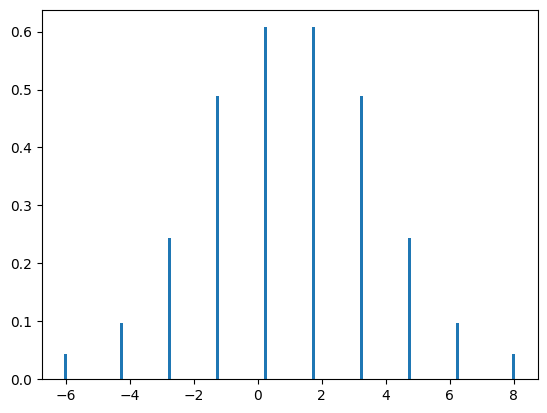

In [ ]:
plt.bar(signatures, sup_bounds, width=0.1)

<BarContainer object of 10 artists>

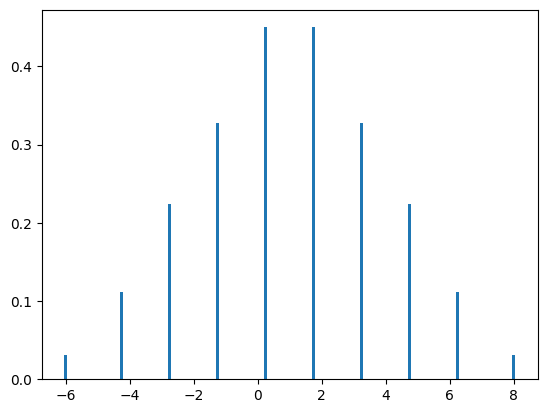

In [ ]:
r_inf = [initial_signature_probas[i]/sup_bounds[i] for i in range(len(sup_bounds))]
plt.bar(signatures, r_inf, width=0.1)

In [ ]:
b, k_index, j_index = [], [], []
for k in range(len(regions)):
    for j in range(len(regions)):
        
        b.append( computeConstantOverapproximation(regions[k], regions[j])**2 )

        k_index.append( k )
        j_index.append( j )



sorted_vectors = sorted(zip(b, k_index, j_index))

# Unzip the sorted tuples back into separate vectors
vector1_sorted, vector2_sorted, vector3_sorted = zip(*sorted_vectors)

# Convert back to lists (optional)
b = list(vector1_sorted)
k_index = list(vector2_sorted)
j_index = list(vector3_sorted)

In [ ]:
alpha_matrix = np.zeros([len(regions), len(regions)])

In [ ]:
# lambda_param = 0.05

# outer_sum = 0

# for i in range(len(regions)):
#     max_value = -np.infty
#     for k in k_index:

#         cte = 0
        
#         #Compute constant
#         alpha_sum = 0

#         for j in j_index:

#             r_check_k = initial_signature_probas[k] / sup_bounds[k]

#             if(k == j):
#                 alpha_kj = 1
#             else:
#                 alpha_kj = 1 - r_check_k

            
#             if(alpha_sum < 1 and alpha_sum + alpha_kj >= 1):
#                 alpha_kj = 1 - alpha_sum

#             if(alpha_sum >= 1):
#                 alpha_kj = 0

#             alpha_sum += alpha_kj

#             alpha_matrix[k][j] = alpha_kj

#             cte += alpha_kj * computeConstantOverapproximation(regions[k], regions[j])**2

#         #Compute projection part
#         project = 0
#         if(signatures[i] <= regions[k][0]):
#             project = regions[k][0] - signatures[i]
#         elif(signatures[i] >= regions[k][1]):
#             project = signatures[i] - regions[k][1]

#         #Compute 
#         value = cte - lambda_param * project**2

#         max_value = max(max_value, value)
    
#     outer_sum += initial_signature_probas[i] * max_value

# outer_sum += lambda_param * dist_initial_sq
# print(outer_sum**0.5)

In [ ]:
(global_lipsc()**2 * dist_initial_sq)**0.5

0.41297997610093373